In [11]:
import os
import mne
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch

raw = mne.io.read_raw_edf(
    '../physionet.org/files/sleep-edfx/1.0.0/sleep-cassette/SC4201E0-PSG.edf',
    preload=True
)

print(raw.info)

Extracting EDF parameters from ../physionet.org/files/sleep-edfx/1.0.0/sleep-cassette/SC4201E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 8411999  =      0.000 ... 84119.990 secs...


/var/folders/hs/4hdxpkyn0g5274r3582nqd_h0000gn/T/ipykernel_5221/2062275771.py:7: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/var/folders/hs/4hdxpkyn0g5274r3582nqd_h0000gn/T/ipykernel_5221/2062275771.py:7: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
/var/folders/hs/4hdxpkyn0g5274r3582nqd_h0000gn/T/ipykernel_5221/2062275771.py:7: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(


<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1989-05-08 16:18:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 51yr>
>


In [5]:
print(raw.ch_names)

['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']


saved ../visualizations/channels_WAKE.png
saved ../visualizations/channels_N1.png
saved ../visualizations/channels_N2.png
saved ../visualizations/channels_N3.png
saved ../visualizations/channels_REM.png


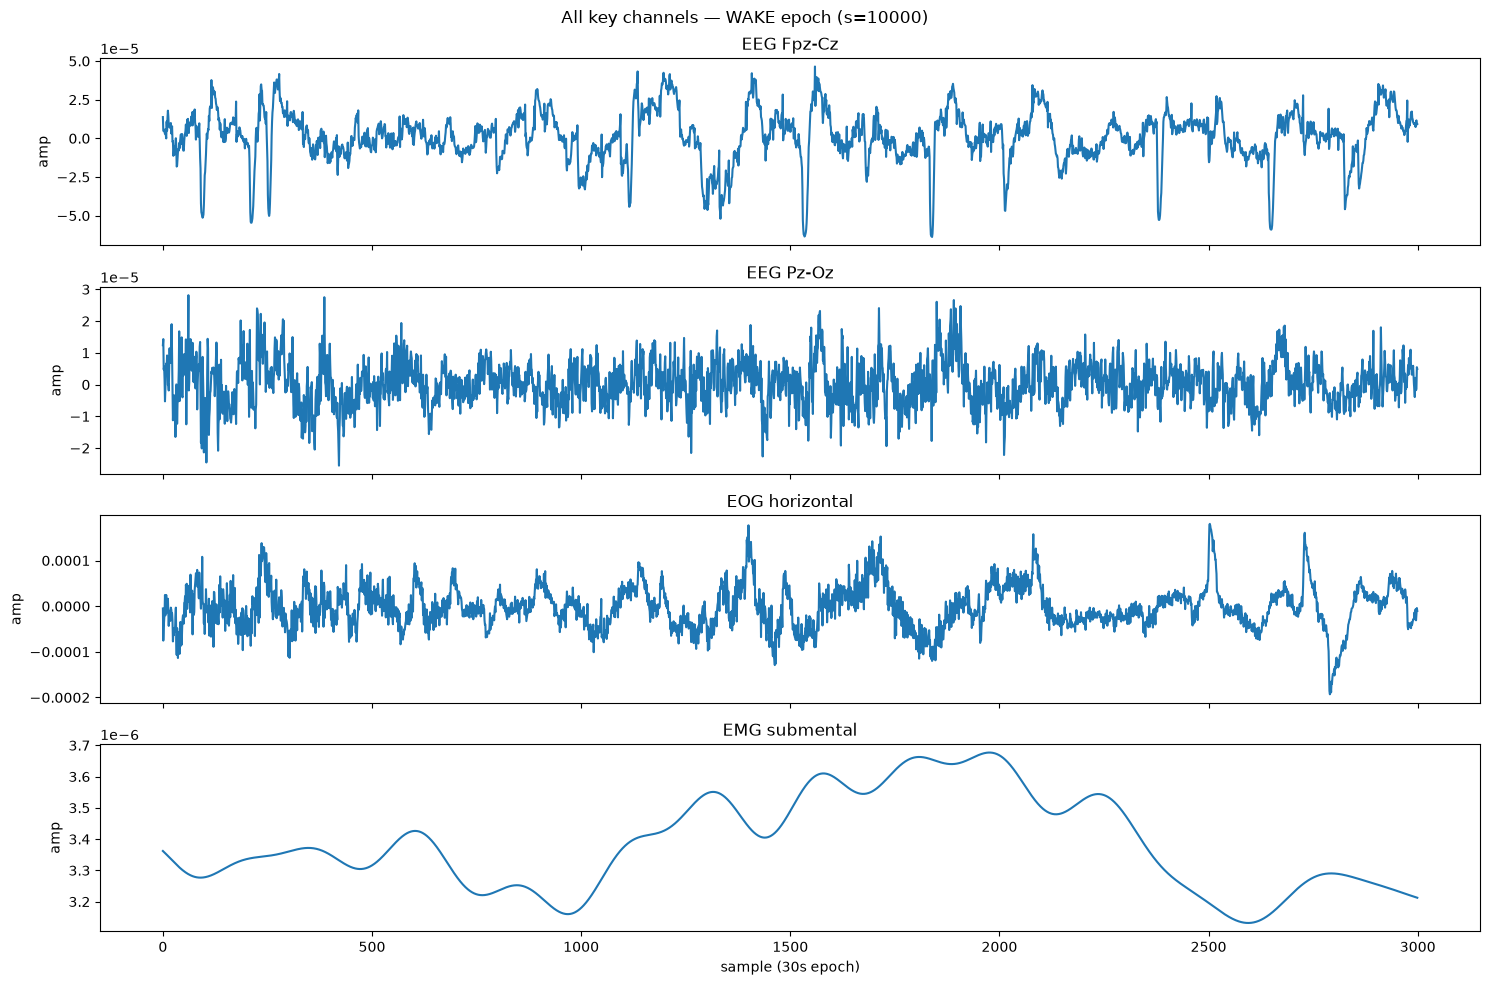

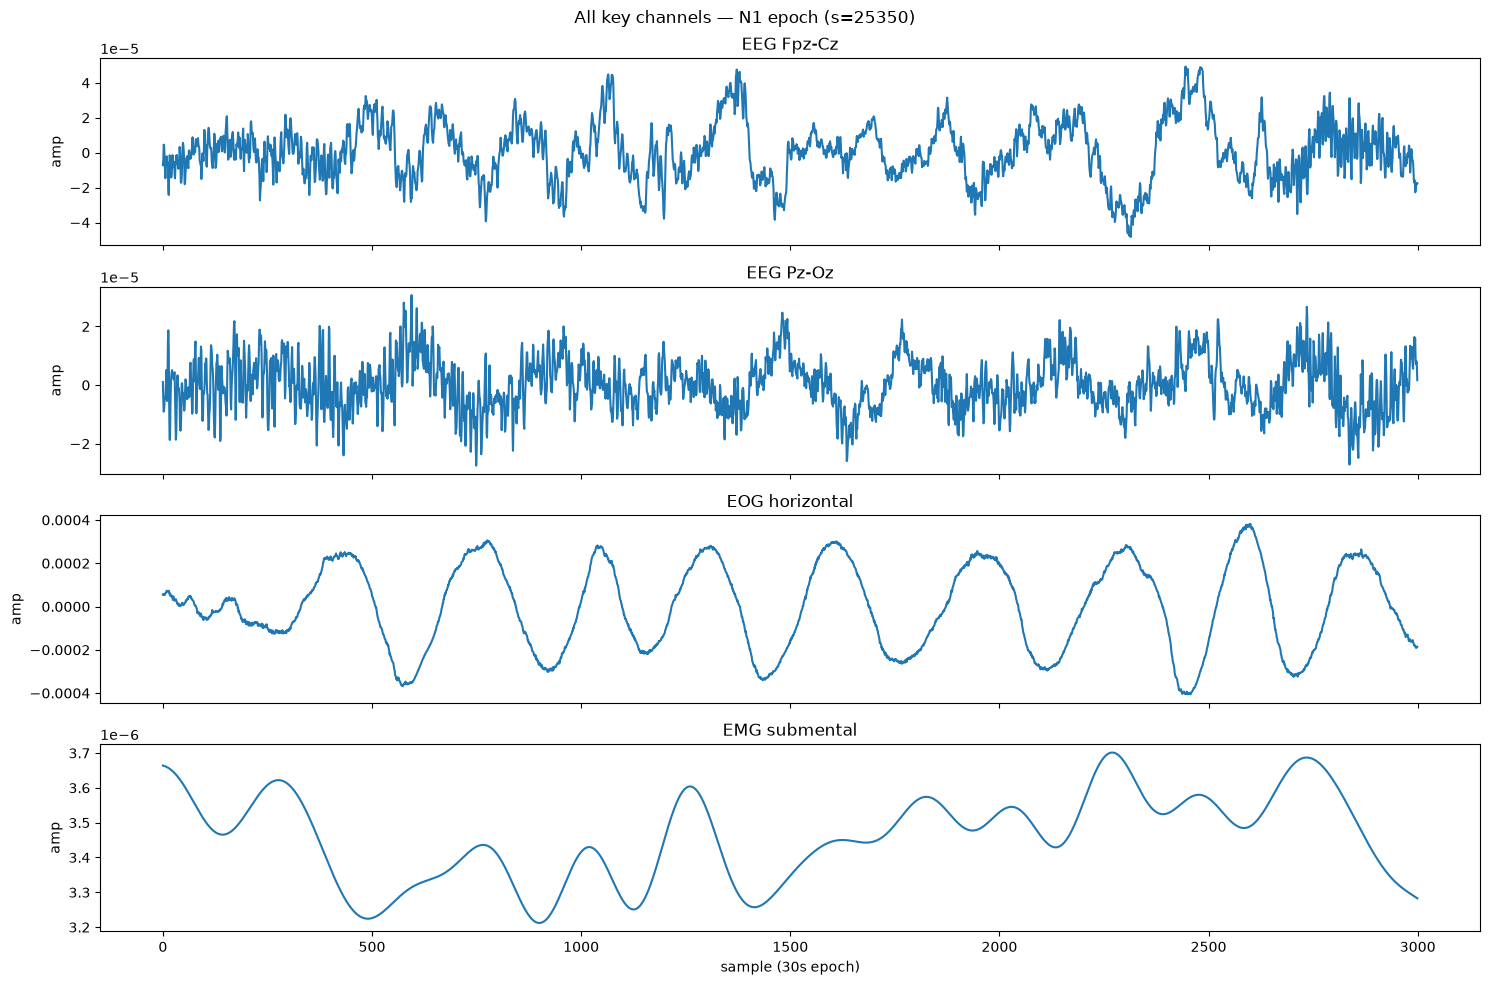

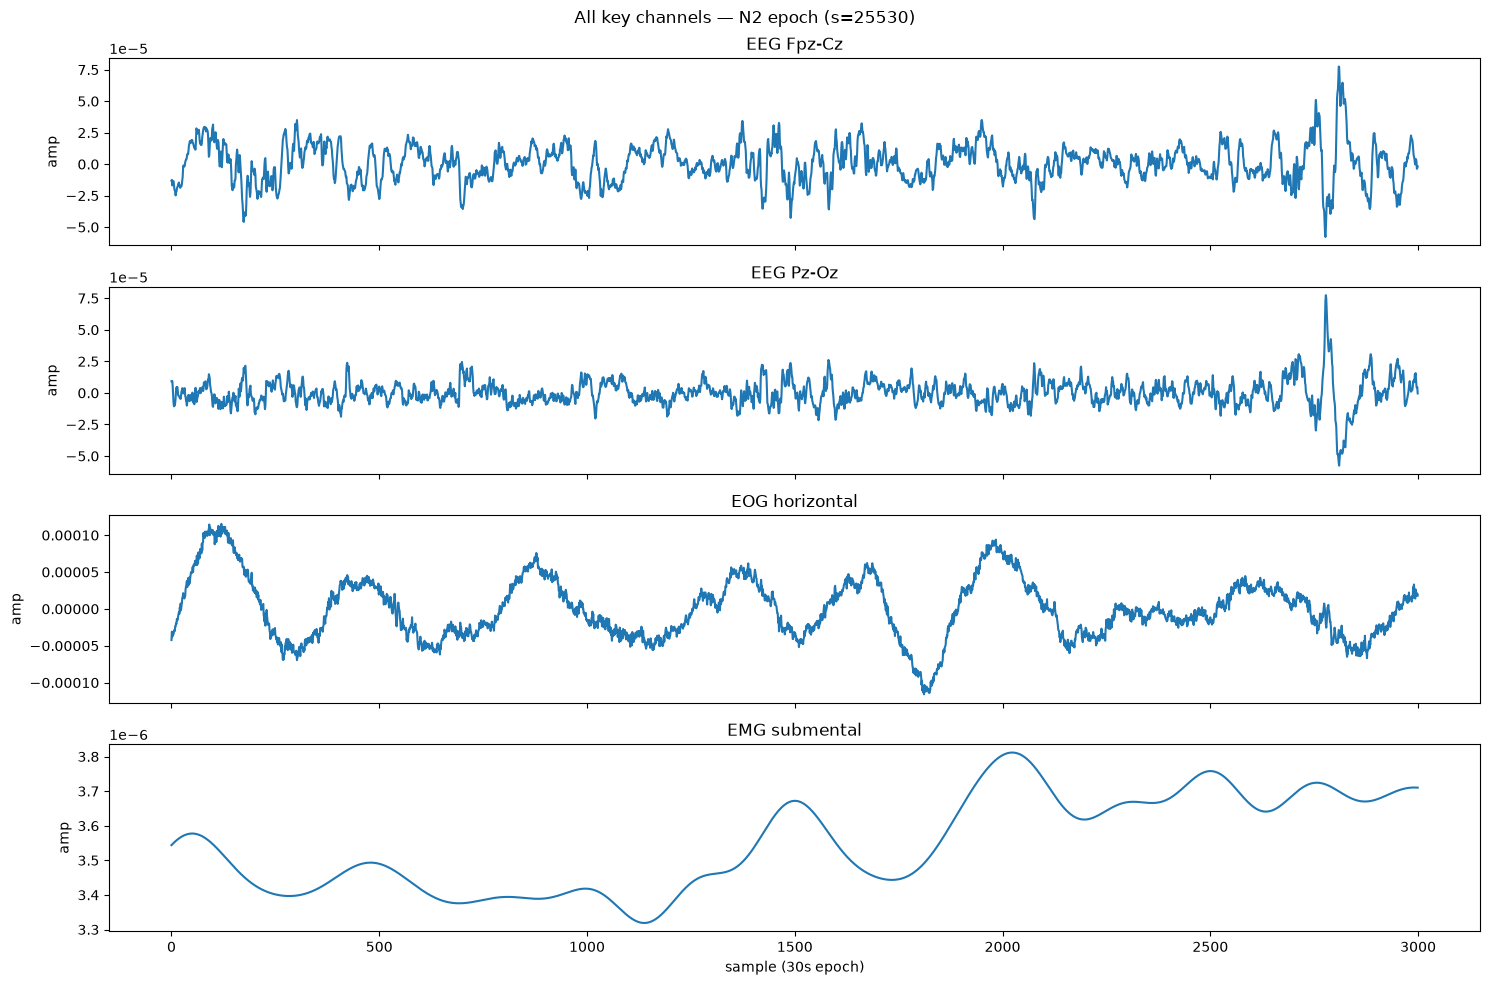

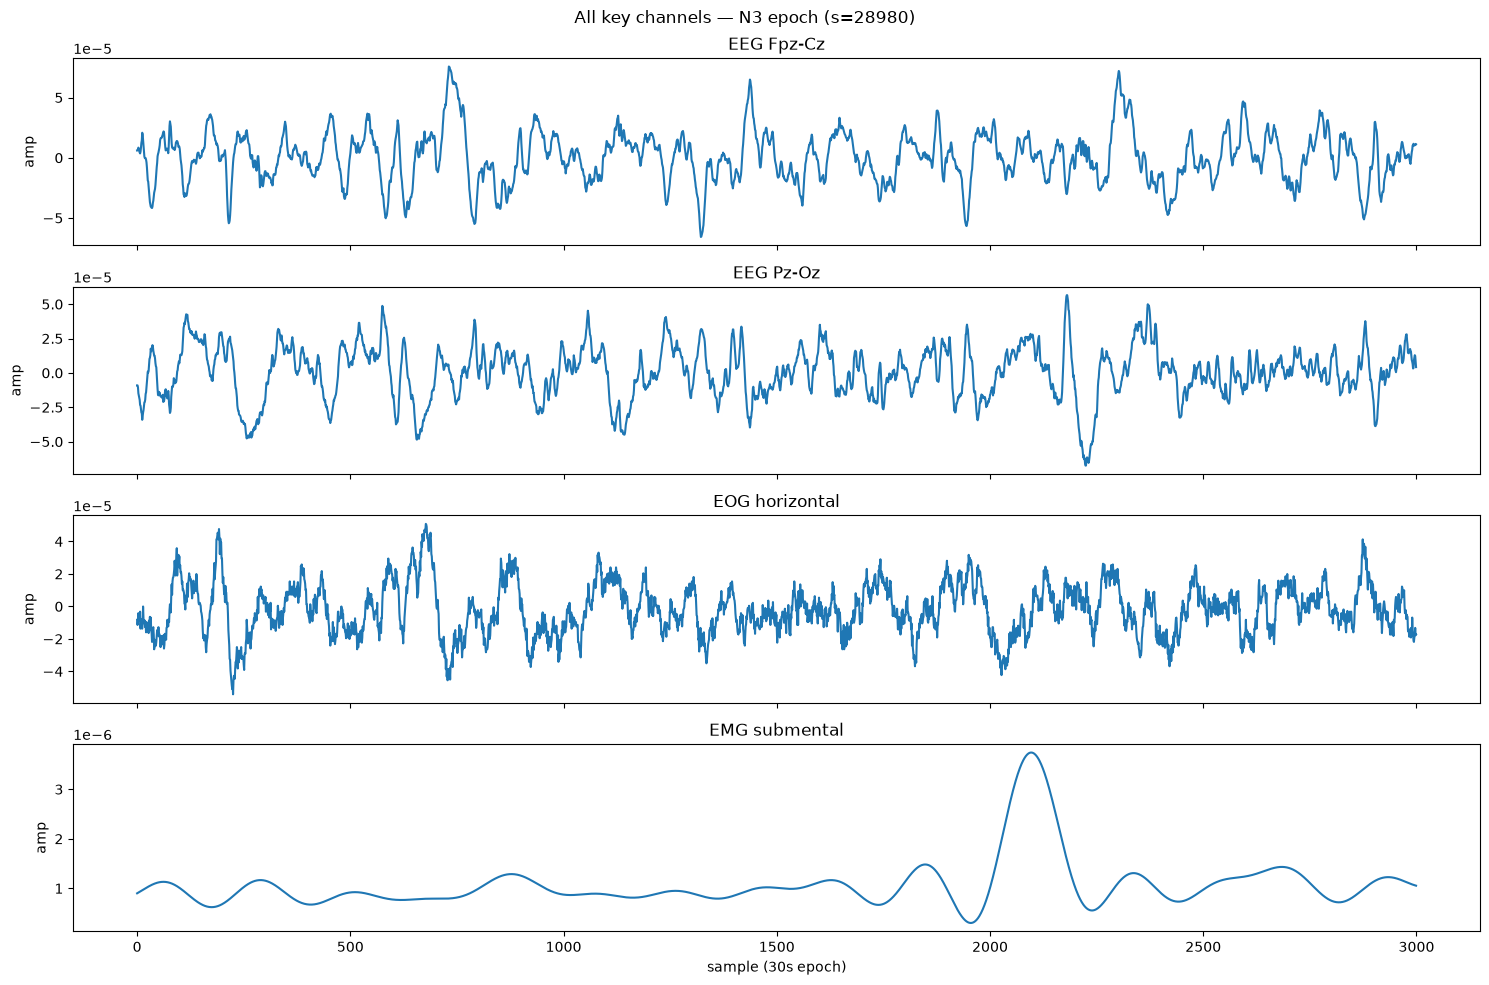

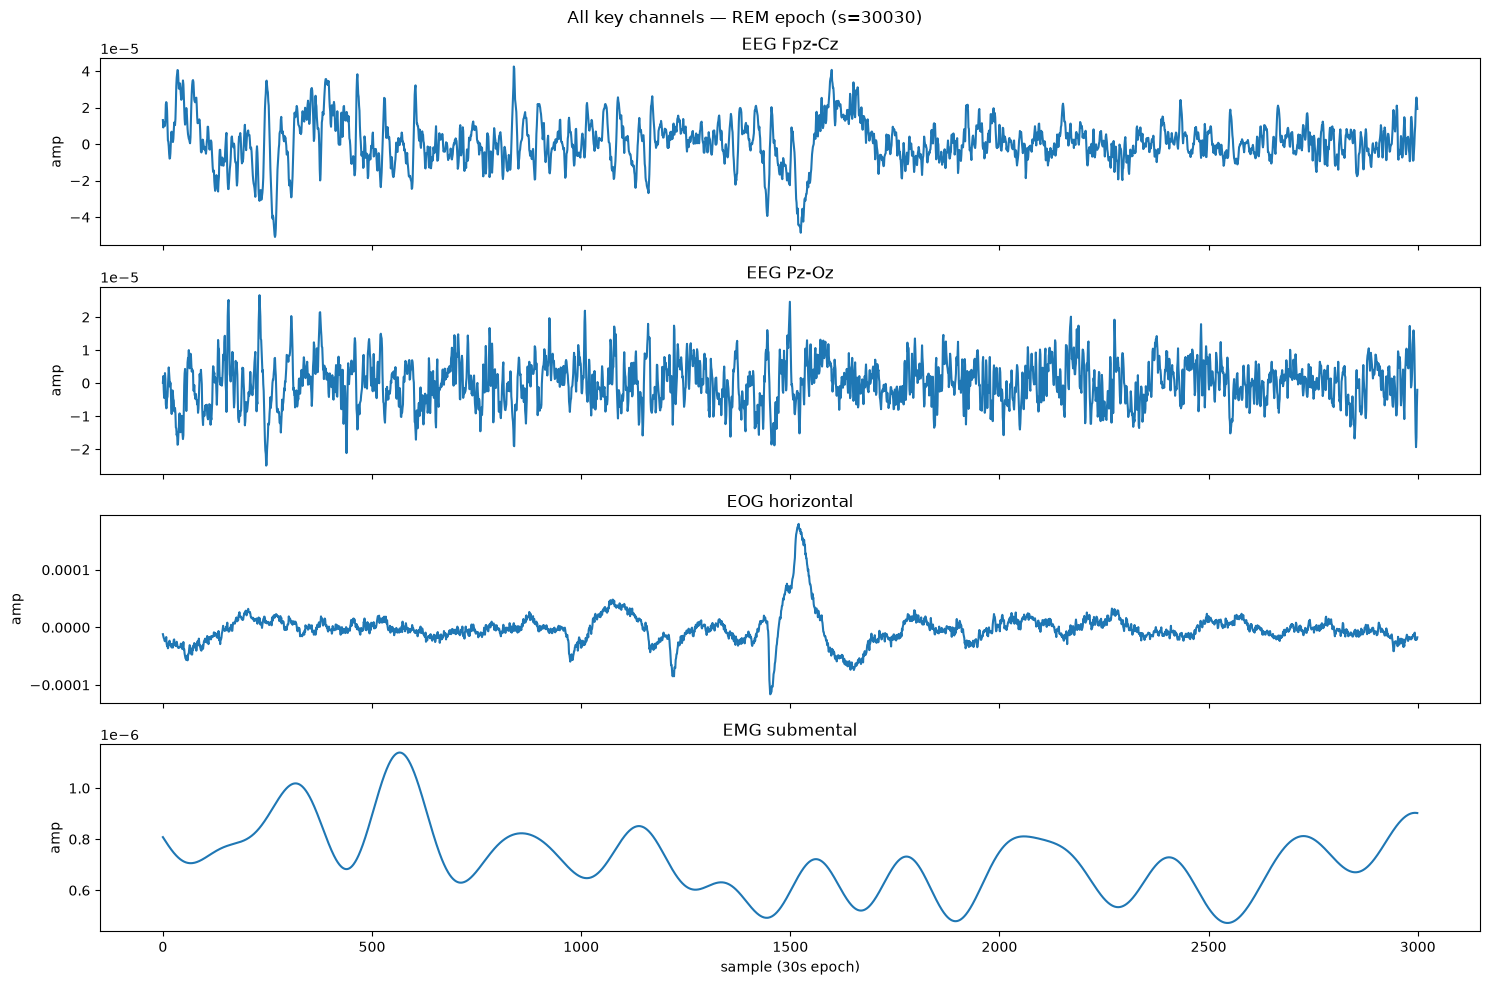

In [13]:
# create the output folder (relative to where the notebook runs)
VIZ_DIR = '../visualizations'
os.makedirs(VIZ_DIR, exist_ok=True)

channels = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']
fs = 100

# one representative epoch (center second) per stage, from the hypnogram
stage_epochs = {
    'WAKE': 10000,
    'N1':   25350,
    'N2':   25530,
    'N3':   28980,
    'REM':  30030,
}

def save_stage_plot(stage, center_sec):
    fig, axes = plt.subplots(len(channels), 1, figsize=(15, 10), sharex=True)
    for ax, ch in zip(axes, channels):
        sig = raw.get_data(picks=[ch])[0]
        epoch = sig[center_sec*fs : (center_sec+30)*fs]
        ax.plot(epoch)
        ax.set_title(ch)
        ax.set_ylabel('amp')
    axes[-1].set_xlabel('sample (30s epoch)')
    fig.suptitle(f'All key channels — {stage} epoch (s={center_sec})')
    fig.tight_layout()

    path = f'{VIZ_DIR}/channels_{stage}.png'
    fig.savefig(path, dpi=100, bbox_inches='tight')
    #plt.close(fig)
    print(f'saved {path}')

for stage, sec in stage_epochs.items():
    save_stage_plot(stage, sec)

In [7]:
annotations = mne.read_annotations(
    '../physionet.org/files/sleep-edfx/1.0.0/sleep-cassette/SC4201EC-Hypnogram.edf'
)

print(annotations)

print("number of annotations:", len(annotations))
print()

for ann in annotations[:]:
    print(f"onset={ann['onset']:>8.1f}s   duration={ann['duration']:>7.1f}s   stage={ann['description']}")
#onset, duration, description are mne conventions

<Annotations | 56 segments: Movement time (1), Sleep stage 1 (15), Sleep ...>
number of annotations: 56

onset=     0.0s   duration=25350.0s   stage=Sleep stage W
onset= 25350.0s   duration=   60.0s   stage=Sleep stage 1
onset= 25410.0s   duration=   60.0s   stage=Sleep stage W
onset= 25470.0s   duration=   60.0s   stage=Sleep stage 1
onset= 25530.0s   duration=  960.0s   stage=Sleep stage 2
onset= 26490.0s   duration=  270.0s   stage=Sleep stage W
onset= 26760.0s   duration=   60.0s   stage=Sleep stage 1
onset= 26820.0s   duration= 1950.0s   stage=Sleep stage 2
onset= 28770.0s   duration=   30.0s   stage=Sleep stage 3
onset= 28800.0s   duration=  180.0s   stage=Sleep stage 2
onset= 28980.0s   duration=   60.0s   stage=Sleep stage 3
onset= 29040.0s   duration=  300.0s   stage=Sleep stage 2
onset= 29340.0s   duration=   30.0s   stage=Sleep stage 3
onset= 29370.0s   duration=  450.0s   stage=Sleep stage 2
onset= 29820.0s   duration=   30.0s   stage=Sleep stage 1
onset= 29850.0s   duratio

In [ ]:
# filter the EEG: bandpass 0.5-30 Hz to remove slow drift + high-freq noise
raw_filtered = raw.copy().filter(l_freq=0.5, h_freq=30, picks=['EEG Fpz-Cz'])
eeg_f = raw_filtered.get_data(picks=['EEG Fpz-Cz'])[0]

def get_epoch_f(center_sec):
    start = center_sec * fs
    return eeg_f[start : start + 30*fs]

# grab all five stages now
epochs = {
    'WAKE': get_epoch_f(10000),
    'N1':   get_epoch_f(25350),
    'N2':   get_epoch_f(25530),
    'N3':   get_epoch_f(28980),
    'REM':  get_epoch_f(30030),
}

BANDS = {
    'delta': (0.5, 4), 
    'theta': (4, 8), 
    'alpha': (8, 13), 
    'beta': (13, 30)
}

def band_powers_pct(epoch, fs=100):
    freqs, psd = welch(epoch, fs=fs, nperseg=fs*2)
    powers = {}
    for name, (low, high) in BANDS.items():
        mask = (freqs >= low) & (freqs < high)
        powers[name] = np.sum(psd[mask])
    total = sum(powers.values())
    return {k: 100*v/total for k, v in powers.items()}

print('After bandpass filtering (0.5-30 Hz):')
for label, ep in epochs.items():
    pct = band_powers_pct(ep)
    print(f'{label:5s}  ' + '  '.join(f'{k}={pct[k]:5.1f}%' for k in BANDS))

Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 661 samples (6.610 s)

After bandpass filtering (0.5-30 Hz):
WAKE   delta= 86.4%  theta=  9.1%  alpha=  1.9%  beta=  2.6%
N1     delta= 82.2%  theta=  6.0%  alpha=  6.5%  beta=  5.3%
N2     delta= 82.2%  theta= 11.5%  alpha=  3.2%  beta=  3.1%
N3     delta= 93.7%  theta=  5.1%  alpha=  0.8%  beta=  0.4%
REM    delta= 69.5%  theta= 18.8%  alpha=  6.9%